# Explainability Analysis Workflow

This notebook turns explainability into a concrete analysis pipeline for crack segmentation.

Main idea:

1. Load one selected non-transformer model and the SegFormer reference.
2. Generate output-level explanation maps that work for both models.
3. Inspect common TP, FP, and FN patterns.
4. Convert explanation signals into a simple prediction filter.
5. Compare metrics before and after filtering.

Recommended starting models from the selection notebook:

- Main non-transformer: `Unet-efficientnet-b0-imagenet`
- Transformer reference: `Segformer-mit_b0-imagenet`

The first round should focus on output-level explanations: probability maps, uncertainty maps, error maps, and connected components. These are easier to justify for filtering than architecture-specific attention maps.

Explainability-guided post-processing using probability, uncertainty, and connected-component confidence maps.

## 1. Setup

Run this section first. It imports the existing project pipeline and defines the three target settings.

In [2]:
from pathlib import Path
import sys
import math

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy import ndimage
from IPython.display import display, Markdown
from fastai.vision.all import imagenet_stats

PROJECT_ROOT = Path('/users/7/yu001011/csci5527/CSCI5527-final')
RUNS_DIR = PROJECT_ROOT / 'baseline_models_scripts' / 'runs'
MODELS_DIR = RUNS_DIR / 'models'

sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / 'baseline_models_scripts'))

from train_ttd import build_model, baseline_model_pipeline, EXPERIMENTS

TARGET_SETTINGS = [
    'Single-TB',
    'Shift-TA_TC-to-TB_10pct',
    'Shift-TA_TB-to-TC_10pct',
]

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cuda', index=0)

## 2. Choose Models and Setting

Start with one setting. After the workflow works, rerun the same cells for the other two settings.

Suggested order:

1. `Single-TB` for sanity check.
2. `Shift-TA_TC-to-TB_10pct` because SegFormer appears weak there.
3. `Shift-TA_TB-to-TC_10pct` because SegFormer is competitive there.

This gives a good story: explainability under normal evaluation, bad domain shift, and relatively strong transformer shift.

In [3]:
SETTING = 'Single-TB'

NON_TRANSFORMER = {
    'label': 'Unet-efficientnet-b0',
    'arch': 'Unet',
    'encoder': 'efficientnet-b0',
    'weights': 'imagenet',
}

TRANSFORMER = {
    'label': 'Segformer-mit_b0',
    'arch': 'Segformer',
    'encoder': 'mit_b0',
    'weights': 'imagenet',
}

assert SETTING in TARGET_SETTINGS
SETTING

'Single-TB'

## 3. Load Data and Models

This uses the same dataloader construction as training, so the normalization and resizing match your checkpoints.

In [4]:
train_dl, val_dl, test_dl, custom_stats, df_test_ready = baseline_model_pipeline(
    base_dir=PROJECT_ROOT,
    dict_files=EXPERIMENTS[SETTING],
    bs=4,
    img_size=512,
)

len(test_dl), df_test_ready.shape

Loading CSV metadata...
Sanitizing training and validation masks...


Sanitizing Masks: 100%|██████████| 424/424 [00:00<00:00, 886.22it/s]


Sanitizing test masks...


Sanitizing Masks: 100%|██████████| 48/48 [00:00<00:00, 1353.02it/s]


Generating Dataloaders...

Pipeline Ready:
 - Training batches: 82
 - Validation batches: 24
 - Testing batches: 12


(12, (48, 7))

In [5]:
def model_name(cfg, setting):
    return f"{cfg['arch']}-{cfg['encoder']}-{cfg['weights']}_{setting}"


def load_segmentation_model(cfg, setting, device=DEVICE):
    name = model_name(cfg, setting)
    ckpt_path = MODELS_DIR / f'{name}.pth'
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Missing checkpoint: {ckpt_path}')
    model = build_model(cfg['arch'], cfg['encoder'], cfg['weights'], classes=2)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state)
    model.to(device).eval()
    return model, name, ckpt_path


cnn_model, cnn_name, cnn_ckpt = load_segmentation_model(NON_TRANSFORMER, SETTING)
segformer_model, segformer_name, segformer_ckpt = load_segmentation_model(TRANSFORMER, SETTING)

display(Markdown(f'Loaded non-transformer: `{cnn_name}`'))
display(Markdown(f'Loaded transformer reference: `{segformer_name}`'))

Loaded non-transformer: `Unet-efficientnet-b0-imagenet_Single-TB`

Loaded transformer reference: `Segformer-mit_b0-imagenet_Single-TB`

## 4. Helper Functions

These helpers produce the core explanation maps:

- `crack_prob`: softmax probability for the crack class.
- `uncertainty`: binary entropy of the prediction probability.
- `error_map`: TP, FP, and FN overlay against the ground truth.
- `component_filter`: a simple explanation-derived filter for false positives.

In [6]:
def denorm_image(img, custom_stats=None):
    stats = custom_stats if custom_stats else imagenet_stats
    mean = torch.tensor(stats[0], device='cpu').view(3, 1, 1)
    std = torch.tensor(stats[1], device='cpu').view(3, 1, 1)
    arr = (img.detach().cpu() * std + mean).permute(1, 2, 0).numpy()
    return np.clip(arr, 0, 1)


def predict_maps(model, images, device=DEVICE):
    model.eval()
    with torch.no_grad():
        logits = model(images.to(device))
        probs = torch.softmax(logits, dim=1)
    crack_prob = probs[:, 1].detach().cpu().numpy()
    pred = logits.argmax(dim=1).detach().cpu().numpy().astype(np.uint8)
    return logits.detach().cpu(), crack_prob, pred


def binary_entropy(prob, eps=1e-8):
    prob = np.clip(prob, eps, 1 - eps)
    ent = -(prob * np.log(prob) + (1 - prob) * np.log(1 - prob))
    return ent / np.log(2.0)


def make_error_rgb(pred, target):
    pred = pred.astype(bool)
    target = target.astype(bool)
    rgb = np.zeros((*target.shape, 3), dtype=float)
    rgb[pred & target] = [0.0, 1.0, 0.0]      # TP: green
    rgb[(~pred) & target] = [1.0, 0.0, 0.0]   # FN: red
    rgb[pred & (~target)] = [1.0, 1.0, 0.0]   # FP: yellow
    return rgb


def pixel_metrics(pred, target, eps=1e-8):
    pred = pred.astype(bool)
    target = target.astype(bool)
    tp = np.logical_and(pred, target).sum()
    fp = np.logical_and(pred, ~target).sum()
    fn = np.logical_and(~pred, target).sum()
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    return {'iou': iou, 'f1': f1, 'precision': precision, 'recall': recall, 'tp': tp, 'fp': fp, 'fn': fn}


def component_filter(
    crack_prob,
    pixel_threshold=0.50,
    min_area=20,
    min_component_mean=0.60,
    min_component_peak=0.80,
):
    raw = crack_prob >= pixel_threshold
    labels, n_labels = ndimage.label(raw)
    kept = np.zeros_like(raw, dtype=bool)
    component_rows = []

    for label_id in range(1, n_labels + 1):
        component = labels == label_id
        values = crack_prob[component]
        area = int(component.sum())
        mean_prob = float(values.mean()) if area else 0.0
        peak_prob = float(values.max()) if area else 0.0
        keep = area >= min_area and mean_prob >= min_component_mean and peak_prob >= min_component_peak
        if keep:
            kept[component] = True
        component_rows.append({
            'label_id': label_id,
            'area': area,
            'mean_prob': mean_prob,
            'peak_prob': peak_prob,
            'keep': keep,
        })

    return kept.astype(np.uint8), pd.DataFrame(component_rows)

## 5. Single-Image Explanation Grid

Start with individual images. The goal is to learn what the maps mean before running aggregate metrics.

Read the grid as:

- Probability high but no GT crack: likely FP candidate.
- Probability low over GT crack: likely FN candidate.
- High uncertainty near prediction boundary: model is not confident.
- High uncertainty over non-crack texture: possible domain shift or confusing background.

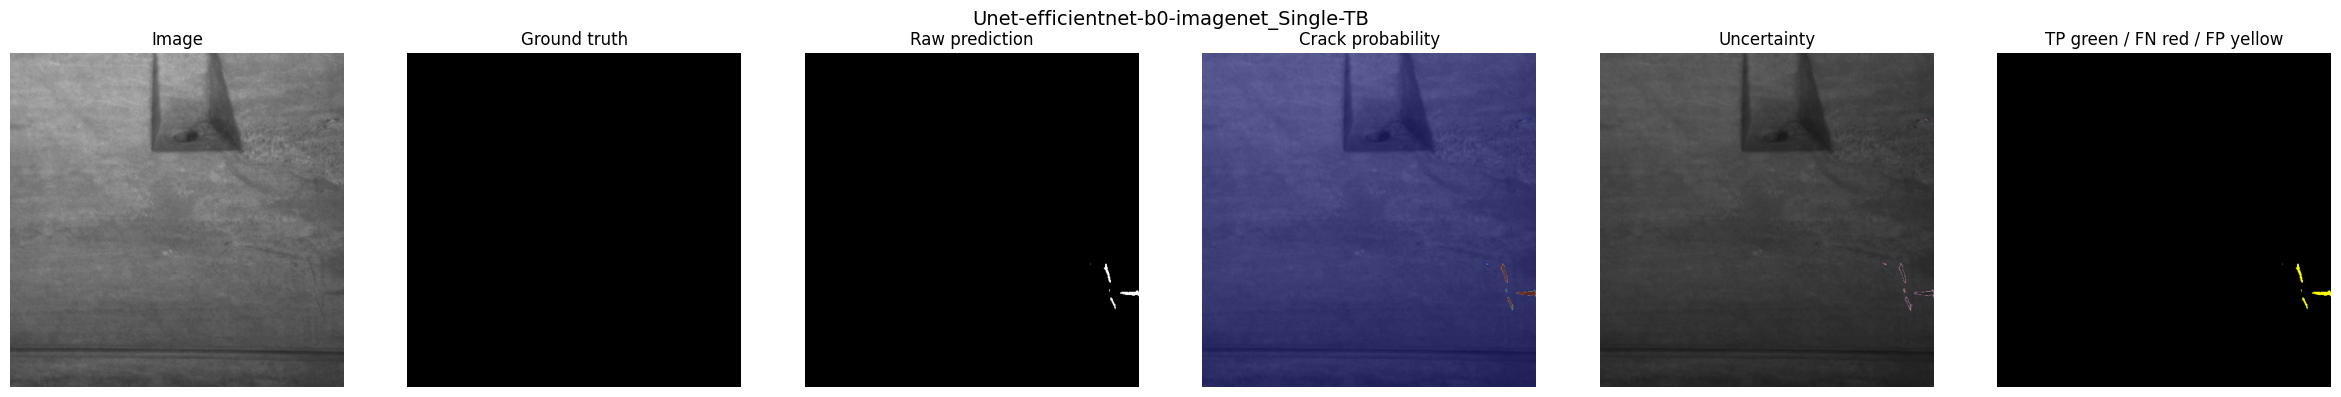

Component summary for `Unet-efficientnet-b0-imagenet_Single-TB`

,label_id,area,mean_prob,peak_prob,keep
3,4,145,0.937474,0.999995,True
1,2,106,0.942311,0.999995,True
4,5,51,0.908708,0.997473,True
2,3,4,0.777190,0.833118,False
0,1,1,0.634748,0.634748,False


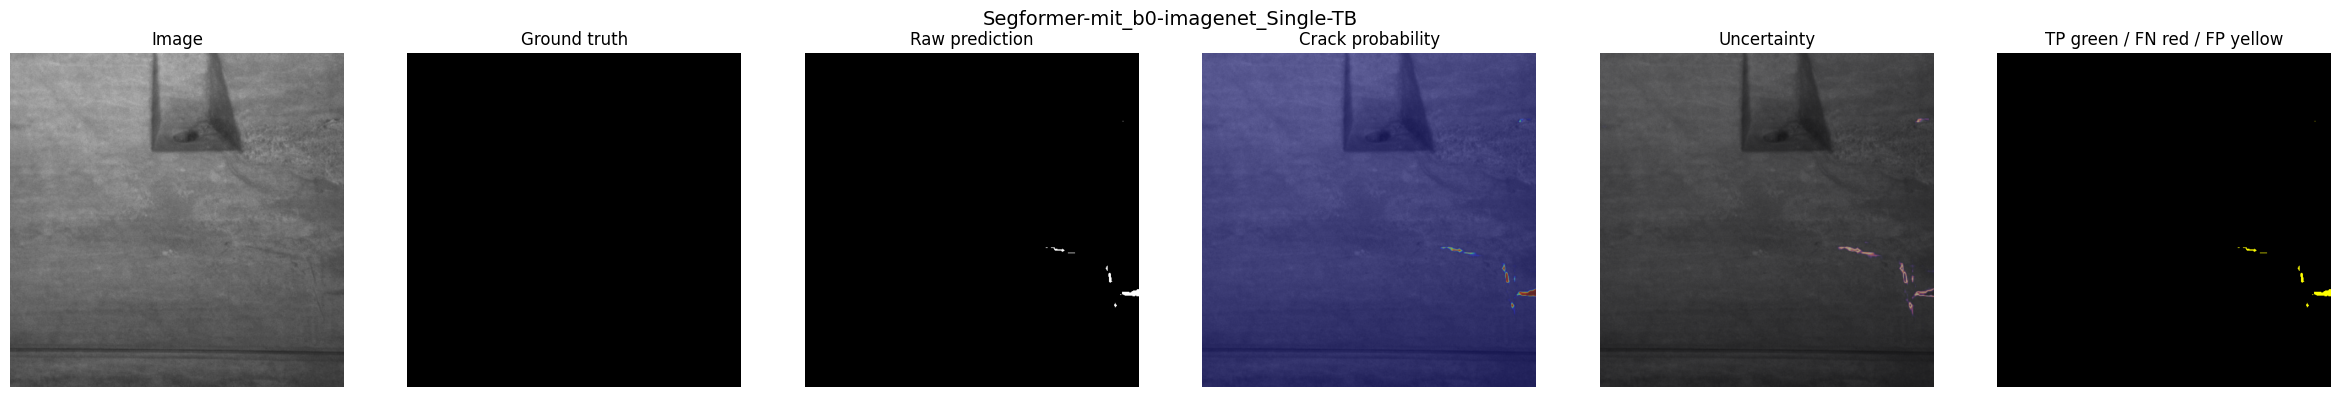

Component summary for `Segformer-mit_b0-imagenet_Single-TB`

,label_id,area,mean_prob,peak_prob,keep
6,7,182,0.888213,0.999767,True
5,6,56,0.846005,0.996416,True
2,3,49,0.701587,0.923358,True
4,5,16,0.790354,0.956117,False
8,9,16,0.763352,0.974674,False
3,4,11,0.676362,0.777135,False
1,2,3,0.617069,0.693991,False
7,8,2,0.549620,0.579818,False
0,1,1,0.612513,0.612513,False


In [7]:
def get_first_positive_batch(dataloader):
    for images, masks in dataloader:
        mask_sum = masks.reshape(masks.shape[0], -1).sum(dim=1)
        if (mask_sum > 0).any():
            return images, masks
    return next(iter(dataloader))


images, masks = get_first_positive_batch(test_dl)
sample_idx = 0
target = masks[sample_idx].squeeze().cpu().numpy().astype(np.uint8)
img_vis = denorm_image(images[sample_idx], custom_stats)

for model, name in [(cnn_model, cnn_name), (segformer_model, segformer_name)]:
    _, crack_prob, pred = predict_maps(model, images[sample_idx:sample_idx+1])
    prob = crack_prob[0]
    pred_mask = pred[0]
    unc = binary_entropy(prob)
    error_rgb = make_error_rgb(pred_mask, target)
    filtered, components = component_filter(prob)

    fig, ax = plt.subplots(1, 6, figsize=(24, 4))
    fig.suptitle(name, fontsize=14)
    ax[0].imshow(img_vis); ax[0].set_title('Image')
    ax[1].imshow(target, cmap='gray'); ax[1].set_title('Ground truth')
    ax[2].imshow(pred_mask, cmap='gray'); ax[2].set_title('Raw prediction')
    ax[3].imshow(img_vis); ax[3].imshow(prob, cmap='jet', alpha=0.45); ax[3].set_title('Crack probability')
    ax[4].imshow(img_vis); ax[4].imshow(unc, cmap='magma', alpha=0.45); ax[4].set_title('Uncertainty')
    ax[5].imshow(error_rgb); ax[5].set_title('TP green / FN red / FP yellow')
    for a in ax:
        a.axis('off')
    plt.tight_layout()
    plt.show()

    display(Markdown(f'Component summary for `{name}`'))
    display(components.sort_values(['keep', 'area'], ascending=[False, False]).head(10))

## 6. Rank Interesting Samples

For the report, do not choose random examples only. Choose examples that reveal behavior:

- high FP: model hallucinates cracks
- high FN: model misses cracks
- high uncertainty: model is confused
- good prediction: sanity-check example

This cell scores each sample, then you can visualize the most interesting ones.

In [8]:
def collect_sample_scores(model, dataloader, max_batches=None):
    rows = []
    sample_counter = 0
    for batch_idx, (images, masks) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        _, crack_prob, pred = predict_maps(model, images)
        targets = masks.squeeze(1).cpu().numpy() if masks.ndim == 4 else masks.cpu().numpy()
        for i in range(images.shape[0]):
            metrics = pixel_metrics(pred[i], targets[i])
            unc = binary_entropy(crack_prob[i])
            rows.append({
                'sample_id': sample_counter,
                'batch_idx': batch_idx,
                'within_batch_idx': i,
                'gt_pixels': int(targets[i].sum()),
                'pred_pixels': int(pred[i].sum()),
                'mean_prob': float(crack_prob[i].mean()),
                'mean_uncertainty': float(unc.mean()),
                **metrics,
            })
            sample_counter += 1
    return pd.DataFrame(rows)


cnn_scores = collect_sample_scores(cnn_model, test_dl)
segformer_scores = collect_sample_scores(segformer_model, test_dl)

display(Markdown(f'CNN samples: {len(cnn_scores)}'))
display(cnn_scores.describe())

/tmp/ipykernel_2484499/2055281328.py:21: RuntimeWarning: divide by zero encountered in log
  ent = -(prob * np.log(prob) + (1 - prob) * np.log(1 - prob))
/tmp/ipykernel_2484499/2055281328.py:21: RuntimeWarning: invalid value encountered in multiply
  ent = -(prob * np.log(prob) + (1 - prob) * np.log(1 - prob))


CNN samples: 48

,sample_id,batch_idx,within_batch_idx,gt_pixels,pred_pixels,mean_prob,mean_uncertainty,iou,f1,precision,recall,tp,fp,fn
count,48.00,48.000000,48.000000,48.000000,48.000000,48.000000,37.000000,4.800000e+01,4.800000e+01,4.800000e+01,4.800000e+01,48.000000,48.000000,48.000000
mean,23.50,5.500000,1.500000,725.416667,558.666667,0.002382,0.003821,2.113178e-01,2.706312e-01,3.283987e-01,6.671731e-01,272.333333,286.333333,453.083333
std,14.00,3.488583,1.129865,1839.900123,819.699746,0.003099,0.002117,2.989176e-01,3.316105e-01,3.783228e-01,3.768066e-01,610.054526,315.788937,1305.559012
min,0.00,0.000000,0.000000,0.000000,0.000000,0.000112,0.001588,9.990010e-12,1.362964e-13,9.990010e-12,1.760563e-11,0.000000,0.000000,0.000000
25%,11.75,2.750000,0.750000,0.000000,54.750000,0.000588,0.002355,5.526843e-11,1.018589e-10,6.922608e-11,3.701770e-01,0.000000,45.500000,0.000000
50%,23.50,5.500000,1.500000,56.000000,255.000000,0.001347,0.003142,3.367003e-10,6.734007e-10,8.328135e-02,8.413422e-01,0.000000,183.000000,43.500000
75%,35.25,8.250000,2.250000,651.750000,768.250000,0.003093,0.004784,3.127847e-01,4.761824e-01,6.538097e-01,1.000000e+00,284.500000,418.000000,332.250000
max,47.00,11.000000,3.000000,11756.000000,4640.000000,0.018066,0.012030,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3467.000000,1336.000000,8289.000000


In [9]:
display(Markdown('### Highest false positives - CNN'))
display(cnn_scores.sort_values('fp', ascending=False).head(10))

display(Markdown('### Highest false negatives - CNN'))
display(cnn_scores.sort_values('fn', ascending=False).head(10))

display(Markdown('### Highest uncertainty - CNN'))
display(cnn_scores.sort_values('mean_uncertainty', ascending=False).head(10))

### Highest false positives - CNN

,sample_id,batch_idx,within_batch_idx,gt_pixels,pred_pixels,mean_prob,mean_uncertainty,iou,f1,precision,recall,tp,fp,fn
28,28,7,0,609,1603,0.006303,0.005268,1.372751e-01,2.414105e-01,1.665627e-01,4.384236e-01,267,1336,342
33,33,8,1,11756,4640,0.018066,NaN,2.681569e-01,4.229080e-01,7.471983e-01,2.949132e-01,3467,1173,8289
0,0,0,0,0,1001,0.004031,0.004759,9.990010e-12,1.998002e-11,9.990010e-12,1.000000e+00,0,1001,0
3,3,0,3,0,818,0.003356,0.005021,1.222494e-11,2.444988e-11,1.222494e-11,1.000000e+00,0,818,0
30,30,7,2,2711,2755,0.010619,NaN,5.871080e-01,7.398463e-01,7.339383e-01,7.458502e-01,2022,733,689
11,11,2,3,1314,1891,0.007321,NaN,6.236069e-01,7.681747e-01,6.509783e-01,9.368341e-01,1231,660,83
43,43,10,3,1031,950,0.003734,0.003363,2.138480e-01,3.523473e-01,3.673684e-01,3.385063e-01,349,601,682
9,9,2,1,528,935,0.003753,NaN,2.992895e-01,4.606972e-01,3.604278e-01,6.382576e-01,337,598,191
24,24,6,0,252,579,0.002321,NaN,1.203369e-11,1.362964e-13,1.727116e-11,3.968254e-11,0,579,252
15,15,3,3,955,1068,0.004200,NaN,4.481031e-01,6.188828e-01,5.861423e-01,6.554974e-01,626,442,329


### Highest false negatives - CNN

,sample_id,batch_idx,within_batch_idx,gt_pixels,pred_pixels,mean_prob,mean_uncertainty,iou,f1,precision,recall,tp,fp,fn
33,33,8,1,11756,4640,0.018066,NaN,2.681569e-01,4.229080e-01,0.747198,2.949132e-01,3467,1173,8289
27,27,6,3,4271,767,0.003118,0.003452,1.790311e-01,3.036919e-01,0.997392,1.791150e-01,765,2,3506
10,10,2,2,2513,772,0.003058,0.004249,1.410212e-01,2.471842e-01,0.525907,1.615599e-01,406,366,2107
19,19,4,3,1994,1177,0.004614,NaN,3.745124e-01,5.449385e-01,0.734070,4.332999e-01,864,313,1130
6,6,1,2,1412,816,0.003246,NaN,3.821340e-01,5.529623e-01,0.754902,4.362606e-01,616,200,796
30,30,7,2,2711,2755,0.010619,NaN,5.871080e-01,7.398463e-01,0.733938,7.458502e-01,2022,733,689
43,43,10,3,1031,950,0.003734,0.003363,2.138480e-01,3.523473e-01,0.367368,3.385063e-01,349,601,682
18,18,4,2,568,0,0.000823,0.009089,1.760563e-11,3.521127e-11,1.000000,1.760563e-11,0,0,568
42,42,10,2,1166,767,0.003084,0.003142,4.892142e-01,6.570098e-01,0.827901,5.445969e-01,635,132,531
8,8,2,0,780,690,0.002781,NaN,2.108731e-01,3.482993e-01,0.371014,3.282051e-01,256,434,524


### Highest uncertainty - CNN

,sample_id,batch_idx,within_batch_idx,gt_pixels,pred_pixels,mean_prob,mean_uncertainty,iou,f1,precision,recall,tp,fp,fn
7,7,1,3,88,140,0.001902,0.012030,4.385965e-11,1.593880e-12,7.142857e-11,1.136364e-10,0,140,88
18,18,4,2,568,0,0.000823,0.009089,1.760563e-11,3.521127e-11,1.000000e+00,1.760563e-11,0,0,568
41,41,10,1,0,0,0.000531,0.006149,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0,0,0
26,26,6,2,0,42,0.000692,0.006051,2.380952e-10,4.761905e-10,2.380952e-10,1.000000e+00,0,42,0
47,47,11,3,0,43,0.000661,0.005732,2.325581e-10,4.651163e-10,2.325581e-10,1.000000e+00,0,43,0
46,46,11,2,0,0,0.000456,0.005427,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0,0,0
28,28,7,0,609,1603,0.006303,0.005268,1.372751e-01,2.414105e-01,1.665627e-01,4.384236e-01,267,1336,342
3,3,0,3,0,818,0.003356,0.005021,1.222494e-11,2.444988e-11,1.222494e-11,1.000000e+00,0,818,0
25,25,6,1,0,269,0.001483,0.004816,3.717472e-11,7.434944e-11,3.717472e-11,1.000000e+00,0,269,0
32,32,8,0,233,227,0.001295,0.004784,2.173913e-11,3.748758e-13,4.405286e-11,4.291845e-11,0,227,233


## 7. Filter/Enhancement Experiment

Now convert explanation into a measurable enhancement.

This first filter is intentionally simple:

1. Convert crack probability map to connected components.
2. Remove tiny components.
3. Remove components with low mean confidence.
4. Remove components with no high-confidence peak.

Expected behavior:

- Precision should improve if many false positives are small/noisy.
- Recall may decrease if true cracks are thin and low confidence.
- F1 tells whether the tradeoff is worth it.

In [10]:
FILTER_PARAMS = {
    'pixel_threshold': 0.50,
    'min_area': 20,
    'min_component_mean': 0.60,
    'min_component_peak': 0.80,
}

FILTER_PARAMS

{'pixel_threshold': 0.5,
 'min_area': 20,
 'min_component_mean': 0.6,
 'min_component_peak': 0.8}

In [11]:
def evaluate_raw_and_filtered(model, dataloader, filter_params):
    raw_totals = {'tp': 0, 'fp': 0, 'fn': 0}
    filt_totals = {'tp': 0, 'fp': 0, 'fn': 0}
    rows = []

    for batch_idx, (images, masks) in enumerate(dataloader):
        _, crack_prob, raw_pred = predict_maps(model, images)
        targets = masks.squeeze(1).cpu().numpy() if masks.ndim == 4 else masks.cpu().numpy()

        for i in range(images.shape[0]):
            filtered_pred, components = component_filter(crack_prob[i], **filter_params)
            raw_metrics = pixel_metrics(raw_pred[i], targets[i])
            filt_metrics = pixel_metrics(filtered_pred, targets[i])

            for key in raw_totals:
                raw_totals[key] += raw_metrics[key]
                filt_totals[key] += filt_metrics[key]

            rows.append({
                'batch_idx': batch_idx,
                'within_batch_idx': i,
                'raw_iou': raw_metrics['iou'],
                'filtered_iou': filt_metrics['iou'],
                'raw_f1': raw_metrics['f1'],
                'filtered_f1': filt_metrics['f1'],
                'raw_precision': raw_metrics['precision'],
                'filtered_precision': filt_metrics['precision'],
                'raw_recall': raw_metrics['recall'],
                'filtered_recall': filt_metrics['recall'],
                'n_components': len(components),
                'n_kept_components': int(components['keep'].sum()) if len(components) else 0,
            })

    def totals_to_metrics(totals):
        tp, fp, fn = totals['tp'], totals['fp'], totals['fn']
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        iou = tp / (tp + fp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        return {'IoU': iou, 'F1': f1, 'Precision': precision, 'Recall': recall, 'TP': tp, 'FP': fp, 'FN': fn}

    summary = pd.DataFrame([
        {'version': 'raw', **totals_to_metrics(raw_totals)},
        {'version': 'filtered', **totals_to_metrics(filt_totals)},
    ])
    return summary, pd.DataFrame(rows)


cnn_filter_summary, cnn_filter_rows = evaluate_raw_and_filtered(cnn_model, test_dl, FILTER_PARAMS)
segformer_filter_summary, segformer_filter_rows = evaluate_raw_and_filtered(segformer_model, test_dl, FILTER_PARAMS)

display(Markdown(f'### Filter summary: {cnn_name}'))
display(cnn_filter_summary)

display(Markdown(f'### Filter summary: {segformer_name}'))
display(segformer_filter_summary)

### Filter summary: Unet-efficientnet-b0-imagenet_Single-TB

,version,IoU,F1,Precision,Recall,TP,FP,FN
0,raw,0.269171,0.424168,0.487470,0.375416,13072,13744,21748
1,filtered,0.269094,0.424072,0.499338,0.368524,12832,12866,21988


### Filter summary: Segformer-mit_b0-imagenet_Single-TB

,version,IoU,F1,Precision,Recall,TP,FP,FN
0,raw,0.234103,0.379389,0.342257,0.425560,14818,28477,20002
1,filtered,0.234996,0.380561,0.347508,0.420563,14644,27496,20176


## 8. Filter Parameter Sweep

After the first filter works, sweep a small grid. Do not over-tune on all settings at once.

Recommended strategy:

1. Tune on `Single-TB` or one validation-like subset.
2. Freeze parameters.
3. Report results on the two shift settings.

This avoids making the filter look better only because it was tuned on the test set.

In [12]:
def sweep_filter_params(model, dataloader, param_grid):
    rows = []
    for params in param_grid:
        summary, _ = evaluate_raw_and_filtered(model, dataloader, params)
        filtered = summary[summary['version'].eq('filtered')].iloc[0].to_dict()
        rows.append({**params, **filtered})
    return pd.DataFrame(rows).sort_values(['F1', 'IoU', 'Precision'], ascending=False)


param_grid = []
for pixel_threshold in [0.45, 0.50, 0.55]:
    for min_area in [10, 20, 40]:
        for min_component_mean in [0.55, 0.60, 0.65]:
            param_grid.append({
                'pixel_threshold': pixel_threshold,
                'min_area': min_area,
                'min_component_mean': min_component_mean,
                'min_component_peak': 0.80,
            })

# This can take a little time. Start with the CNN model, then repeat for SegFormer if needed.
cnn_sweep = sweep_filter_params(cnn_model, test_dl, param_grid)
display(cnn_sweep.head(15))

,pixel_threshold,min_area,min_component_mean,min_component_peak,version,IoU,F1,Precision,Recall,TP,FP,FN
2,0.45,10,0.65,0.8,filtered,0.271874,0.427517,0.489551,0.379437,13212,13776,21608
0,0.45,10,0.55,0.8,filtered,0.271539,0.427103,0.488465,0.379437,13212,13836,21608
1,0.45,10,0.60,0.8,filtered,0.271539,0.427103,0.488465,0.379437,13212,13836,21608
5,0.45,20,0.65,0.8,filtered,0.271042,0.426488,0.494340,0.375014,13058,13357,21762
3,0.45,20,0.55,0.8,filtered,0.270924,0.426342,0.493948,0.375014,13058,13378,21762
4,0.45,20,0.60,0.8,filtered,0.270924,0.426342,0.493948,0.375014,13058,13378,21762
9,0.50,10,0.55,0.8,filtered,0.270209,0.425455,0.493963,0.373636,13010,13328,21810
10,0.50,10,0.60,0.8,filtered,0.270209,0.425455,0.493963,0.373636,13010,13328,21810
11,0.50,10,0.65,0.8,filtered,0.270209,0.425455,0.493963,0.373636,13010,13328,21810
12,0.50,20,0.55,0.8,filtered,0.269094,0.424072,0.499338,0.368524,12832,12866,21988


## 9. Generic Gradient Saliency

This is architecture-agnostic and works for both models. It answers:

> Which input pixels most affect the crack score?

Use it as qualitative evidence. For filtering, prefer output-level maps because they are easier to quantify.

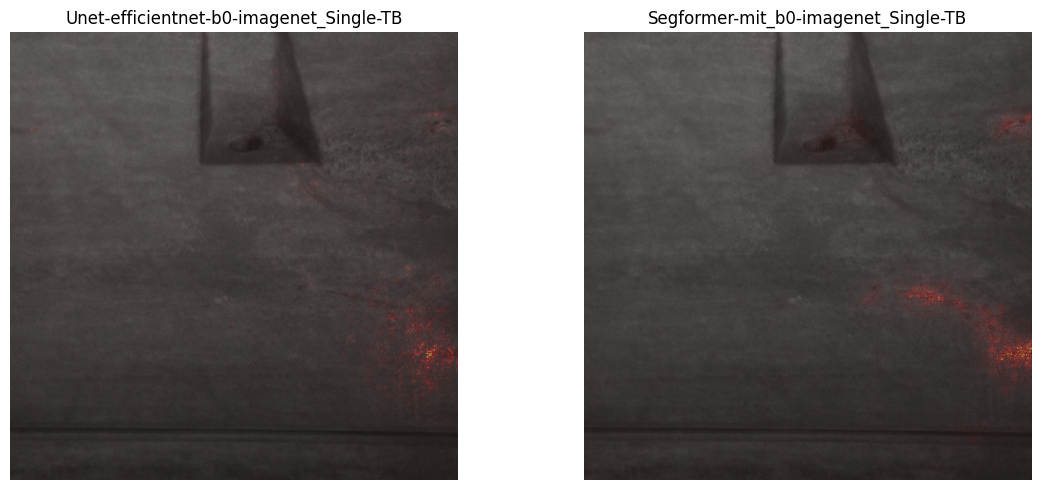

In [13]:
def gradient_saliency(model, image, mask=None, device=DEVICE):
    model.eval()
    x = image.unsqueeze(0).to(device).clone().detach().requires_grad_(True)
    logits = model(x)
    crack_logits = logits[:, 1]

    if mask is not None and mask.sum() > 0:
        region = mask.squeeze().to(device).bool().unsqueeze(0)
    else:
        region = logits.argmax(dim=1).bool()

    if region.sum() == 0:
        score = crack_logits.mean()
    else:
        score = crack_logits[region].mean()

    model.zero_grad(set_to_none=True)
    score.backward()
    saliency = x.grad.abs().max(dim=1).values[0].detach().cpu().numpy()
    saliency = saliency / (saliency.max() + 1e-8)
    return saliency


sal_cnn = gradient_saliency(cnn_model, images[sample_idx], masks[sample_idx])
sal_segformer = gradient_saliency(segformer_model, images[sample_idx], masks[sample_idx])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img_vis); ax[0].imshow(sal_cnn, cmap='hot', alpha=0.45); ax[0].set_title(cnn_name)
ax[1].imshow(img_vis); ax[1].imshow(sal_segformer, cmap='hot', alpha=0.45); ax[1].set_title(segformer_name)
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

## 10. How to Write the Analysis

A strong report section can be organized like this:

1. **Model choice:** explain why `Unet-efficientnet-b0-imagenet` is selected as the main non-transformer model, and why SegFormer is the transformer reference.
2. **Qualitative explanation:** show probability, uncertainty, and error maps for representative good, FP-heavy, and FN-heavy samples.
3. **Failure pattern:** describe whether false positives come from shadow, tunnel seams, water/leaching-like texture, or noisy small components.
4. **Filter design:** define the component confidence filter using probability map and connected components.
5. **Quantitative effect:** compare raw vs filtered IoU/F1/precision/recall.
6. **Tradeoff:** discuss whether precision improves at the cost of recall, especially for thin cracks.
7. **CNN vs transformer:** compare whether the same filter helps both models and whether SegFormer explanations look more global or more unstable under shift.

Important: if you tune filter parameters on one setting, freeze them before reporting the shift settings. That makes the enhancement more credible.